# Predictive maintenance: executed analysis

Synthetic AI4I milling data. This notebook inspects the immutable source, frozen model, independent test results, explanations, and interfaces. Training is executed by `python -m src.train`; this notebook does not select models after test disclosure. No future horizon or remaining useful life is inferred.

In [1]:
from pathlib import Path
import sys, json
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Image
from src.common import read_json
from src.data_validation import load_dataset
from src.feature_engineering import FEATURES
from src.predict import Predictor
print('Python:',sys.version)
print('Project:',ROOT)

Python: 3.12.14 (main, Aug 25 2026, 14:01:42) [MSC v.1944 64 bit (AMD64)]
Project: C:\Users\vanda\OneDrive\Documents\ChatGPT\predictive maintenance agent for manufacturing\predictive_maintenance


## Source, provenance, and validation
Only the original UCI AI4I 2020 dataset is used. Sensor semantics match this pilot. Cross-factory transfer has not been validated.

In [2]:
df=load_dataset()
manifest=read_json(ROOT/'data/raw/manifest.json')
display(manifest)
print('Shape:',df.shape)
display(df.head())
quality=read_json(ROOT/'reports/data_quality_report.json')
display({k:quality[k] for k in ['missing','duplicate_full_records','duplicate_predictor_records','failure_prevalence','overall_label_disagrees_with_mode_union']})
display(df.describe(include='all'))

{'name': 'AI4I 2020 Predictive Maintenance Dataset',
 'owner': 'Stephan Matzka; distributed by UCI Machine Learning Repository',
 'official_page': 'https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset',
 'direct_url': 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip',
 'doi': '10.24432/C5HS5C',
 'downloaded_at_utc': '2026-09-09T10:08:25.462358+00:00',
 'version': '2020 UCI release; exact bytes identified by SHA-256',
 'license': 'CC BY 4.0',
 'license_url': 'https://creativecommons.org/licenses/by/4.0/',
 'intended_use': 'Synthetic milling operating-condition binary/multilabel classification and novelty detection; no forecast horizon or RUL',
 'files': [{'local_filename': 'data\\raw\\ai4i2020_uci_original.zip',
   'sha256': 'f601f14294bcf190f9d720676b7f0aea46a26cde9ab8ebc7b4f8174d9d26b252',
   'bytes': 522170},
  {'local_filename': 'data\\raw\\ai4i2020.csv',
   'sha256': 'dc6630cd9b1f0f853922fad78a1b6436570d3f1ec863

Shape: (10000, 14)


,UDI,Product ID,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


{'missing': {'UDI': 0,
  'Product ID': 0,
  'product_type': 0,
  'air_temperature': 0,
  'process_temperature': 0,
  'rotational_speed': 0,
  'torque': 0,
  'tool_wear': 0,
  'Machine failure': 0,
  'TWF': 0,
  'HDF': 0,
  'PWF': 0,
  'OSF': 0,
  'RNF': 0},
 'duplicate_full_records': 0,
 'duplicate_predictor_records': 0,
 'failure_prevalence': 0.0339,
 'overall_label_disagrees_with_mode_union': {'count': 27,
  'zero_based_row_indices': [1221,
   1302,
   1437,
   1748,
   2072,
   2559,
   2749,
   3065,
   3452,
   4044,
   4684,
   5471,
   5489,
   5495,
   5509,
   5536,
   5553,
   5639,
   5941,
   6091,
   6478,
   6913,
   6960,
   7488,
   7868,
   8506,
   9015],
  'policy': 'Preserve original labels; train overall and modes separately, report inconsistency.'}}

,UDI,Product ID,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


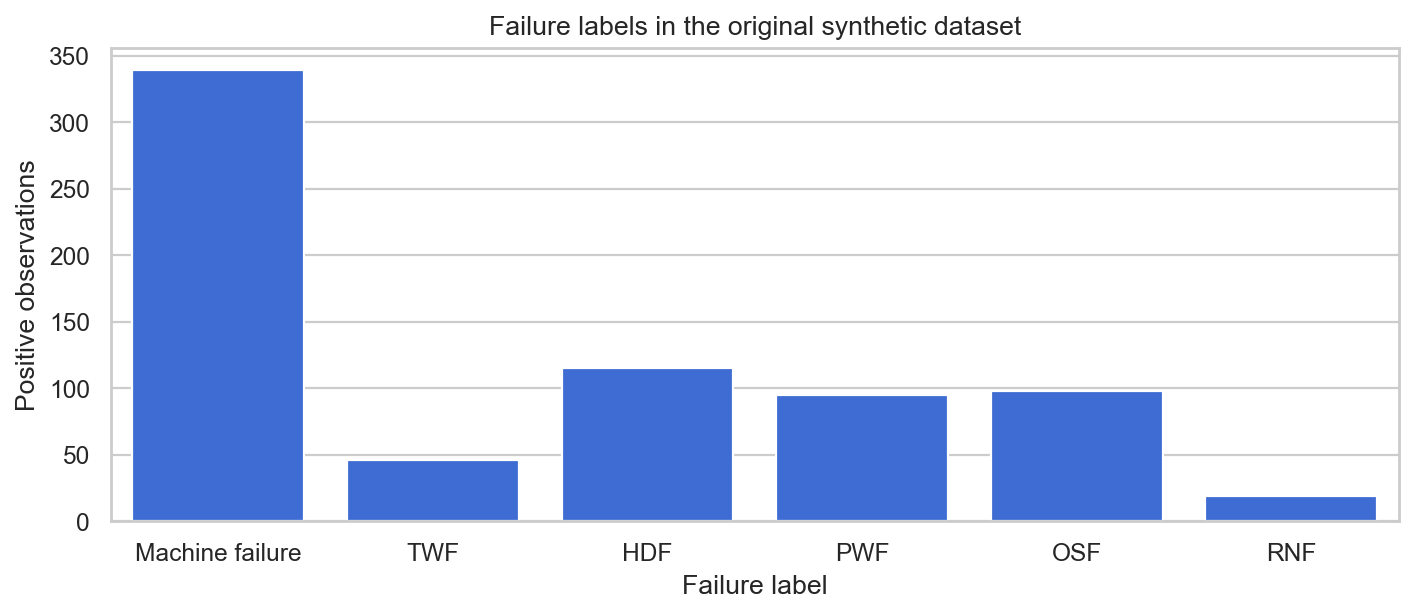

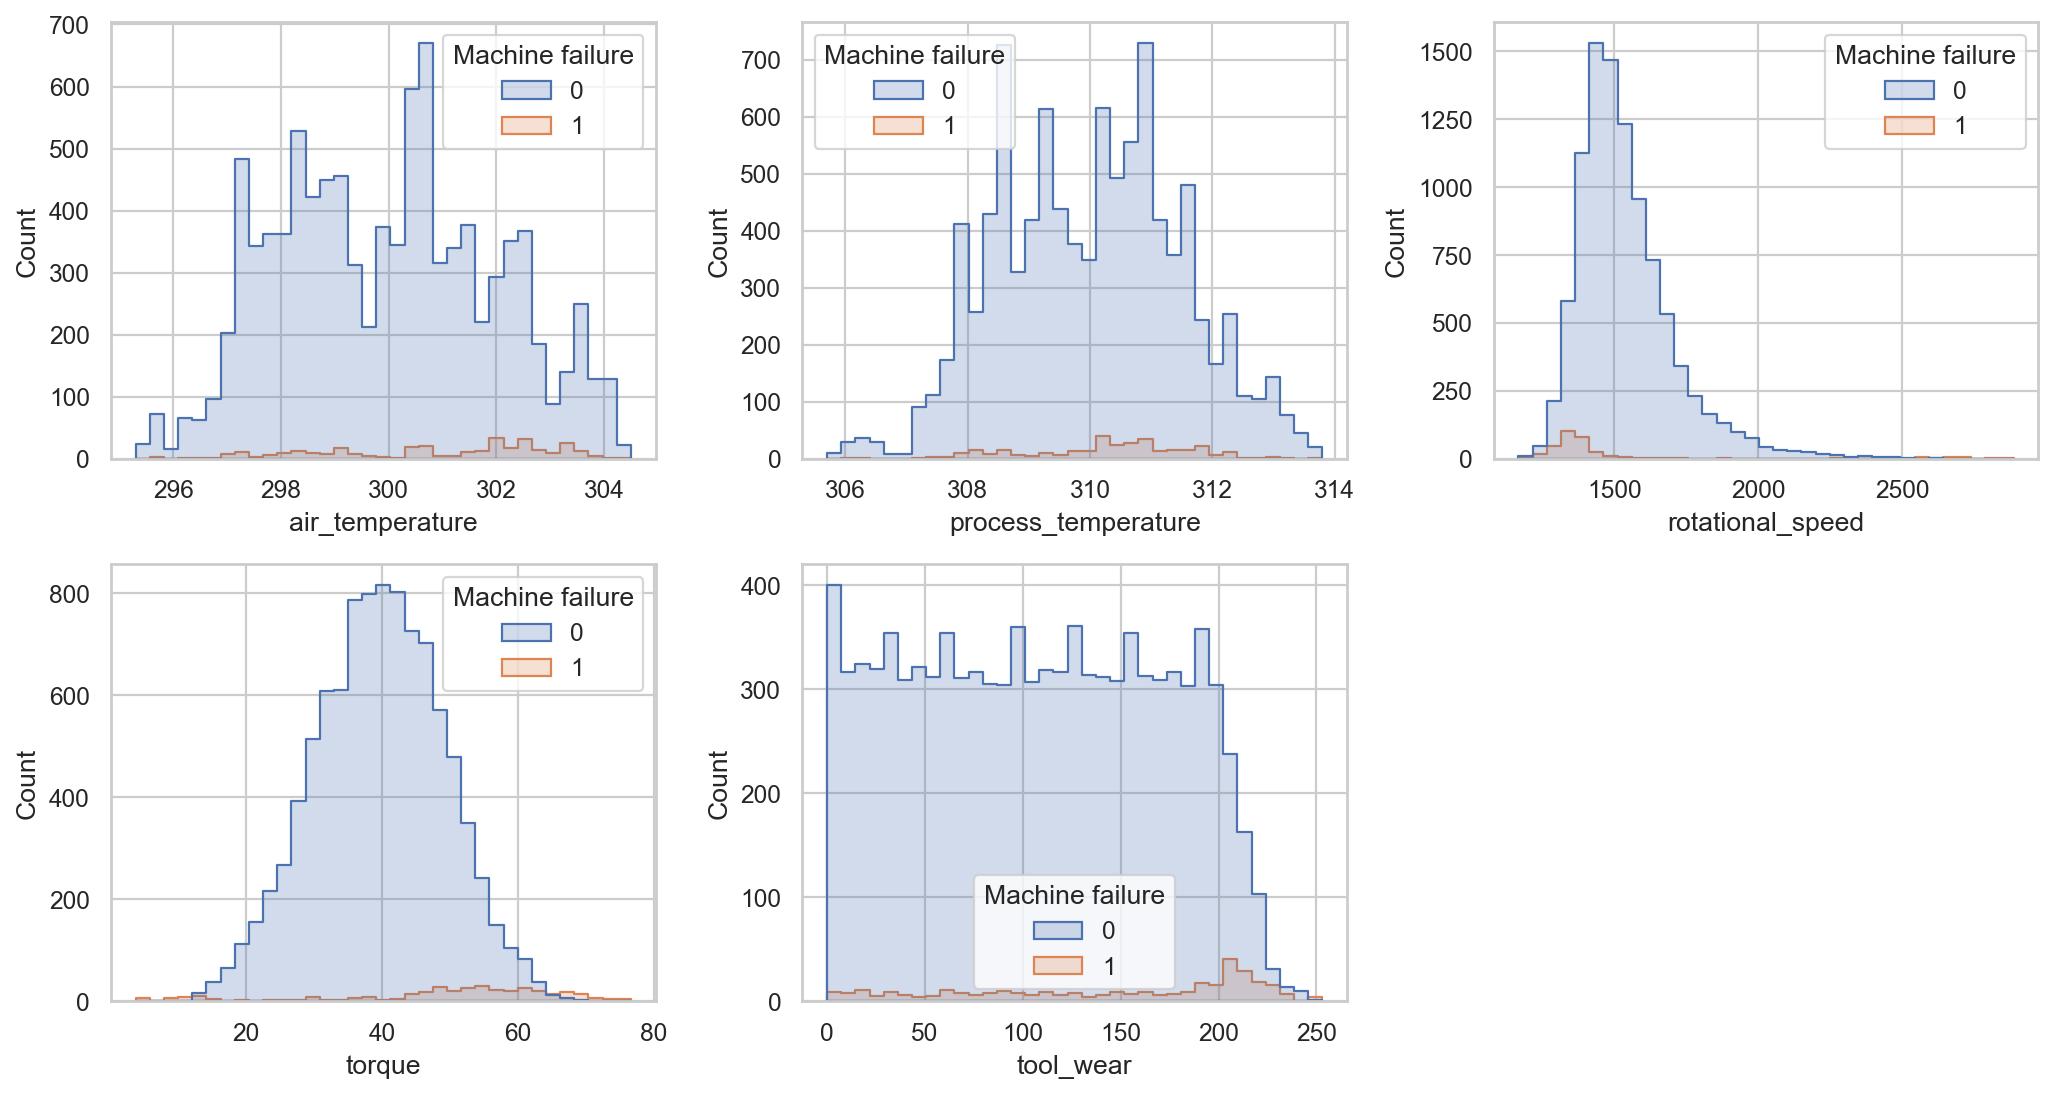

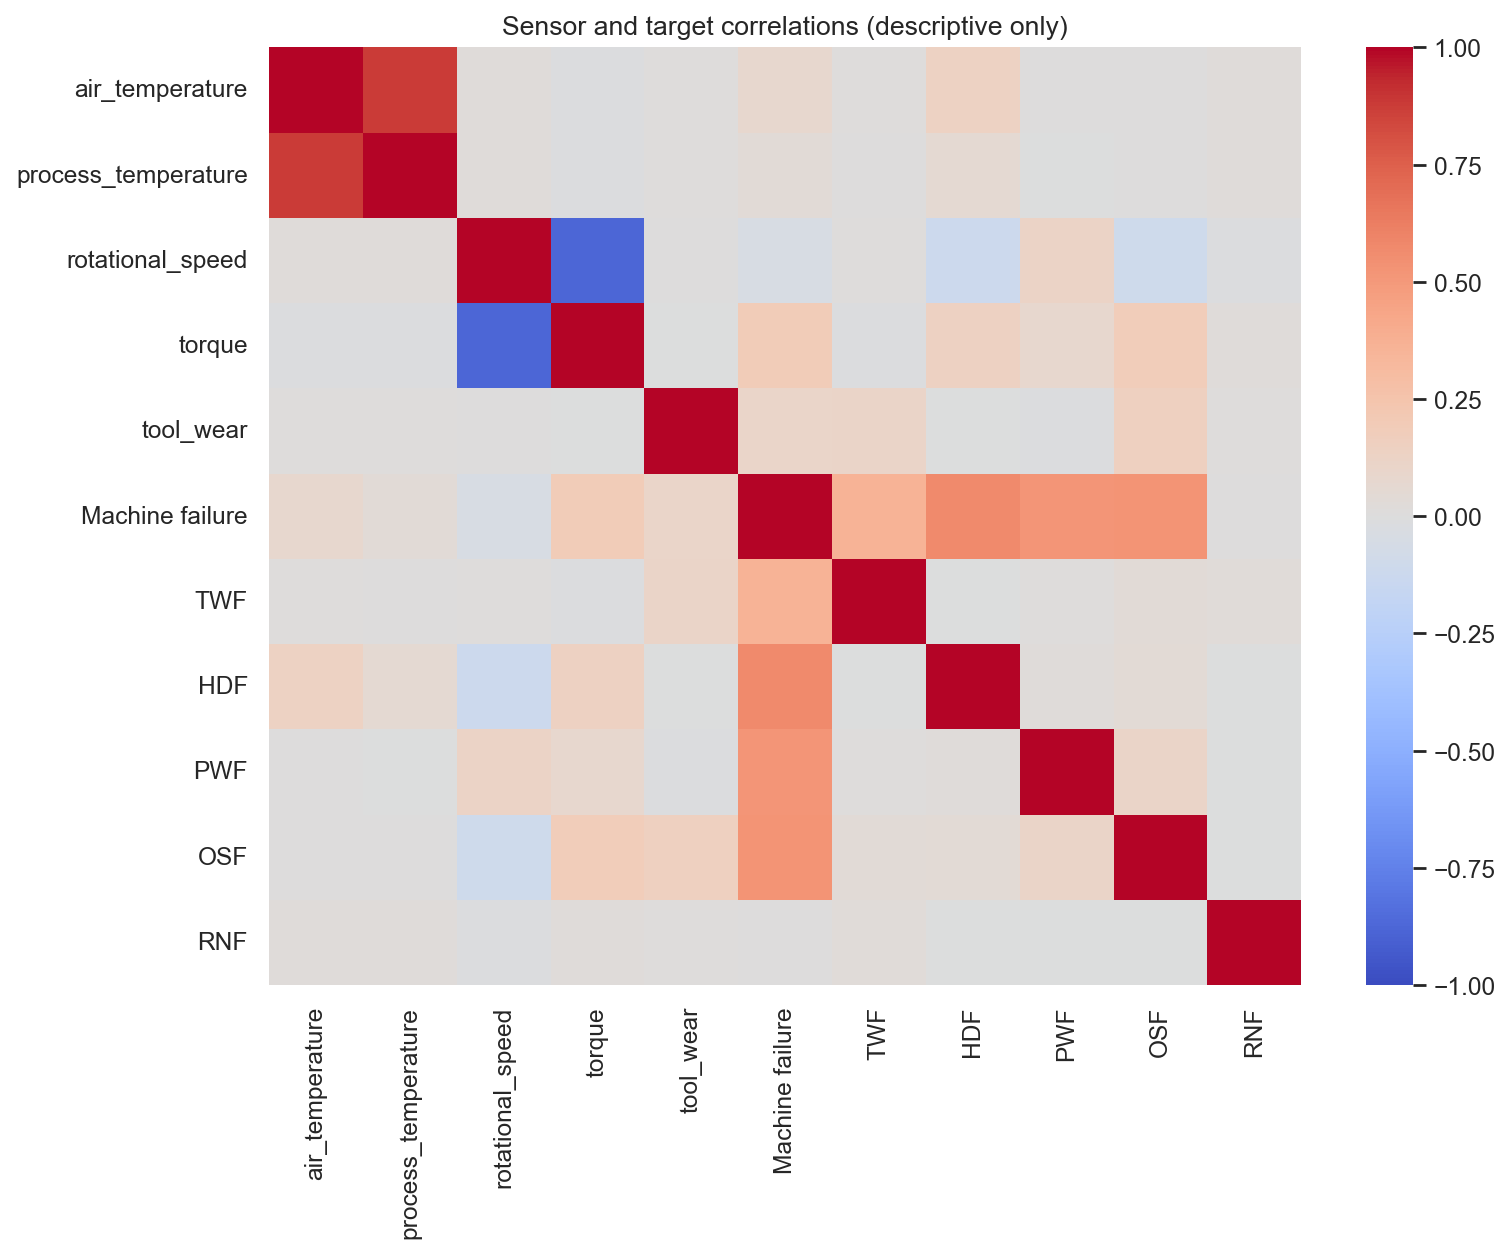

In [3]:
for figure in ['target_distributions.png','numeric_feature_distributions.png','correlation_matrix.png']:
    display(Image(filename=str(ROOT/'reports/figures'/figure)))

## Leakage controls and split protocol
60/20/20 stratification with seed 42. Only the six allowed raw inputs enter any component. Imputation and encoding are fitted inside each training fold. Five-fold CV and bounded tuning use only training rows; thresholds use validation rows. Random row splitting is an in-dataset benchmark and does not demonstrate temporal early warning.

In [4]:
split=read_json(ROOT/'data/processed/split_indices.json')
sets={k:set(v) for k,v in split.items()}
assert not sets['train']&sets['test'] and not sets['validation']&sets['test'] and not sets['train']&sets['validation']
print({k:len(v) for k,v in sets.items()})
comparison=pd.read_csv(ROOT/'reports/metrics/model_comparison.csv')
display(comparison[['candidate','cv_pr_auc_mean','cv_pr_auc_std','validation_precision','validation_recall','validation_f1','validation_pr_auc','validation_brier_score','validation_cost','selected_threshold']])

{'train': 6000, 'validation': 2000, 'test': 2000}


,candidate,cv_pr_auc_mean,cv_pr_auc_std,validation_precision,validation_recall,validation_f1,validation_pr_auc,validation_brier_score,validation_cost,selected_threshold
0,dummy,0.033833,0.000456,0.034000,1.000000,0.065764,0.034000,0.032844,1932.0,0.033833
1,logistic_regression,0.489479,0.070810,0.204461,0.808824,0.326409,0.434578,0.114758,279.0,0.608565
2,random_forest,0.900197,0.047803,0.774648,0.808824,0.791367,0.860643,0.010243,81.0,0.279040
3,hist_gradient_boosting,0.866853,0.033987,0.705128,0.808824,0.753425,0.843447,0.012700,88.0,0.337875
4,xgboost,0.877865,0.063478,0.625000,0.808824,0.705128,0.841369,0.023769,98.0,0.567311
5,random_forest_tuned,0.899377,0.047829,0.705128,0.808824,0.753425,0.855937,0.010078,88.0,0.190000
6,random_forest_tuned_sigmoid,NaN,NaN,0.705128,0.808824,0.753425,0.855937,0.009533,88.0,0.044387
7,xgboost_tuned,0.884337,0.048108,0.518182,0.838235,0.640449,0.843347,0.016621,108.0,0.329144
8,xgboost_tuned_sigmoid,NaN,NaN,0.518182,0.838235,0.640449,0.843347,0.011516,108.0,0.040988


## Frozen model selection and test metrics
The pilot assumes a missed failure costs five false alarms and seeks validation recall of at least 0.80. These are configurable assumptions requiring factory approval. Calibration candidates were evaluated on validation data. CV after hyperparameter selection is not a nested unbiased estimate. The final test was evaluated only after selection was frozen.

In [5]:
metadata=read_json(ROOT/'models/model_metadata.json')
threshold=read_json(ROOT/'models/threshold.json')
display(threshold)
for name in ['validation_metrics','test_metrics','test_metrics_by_product_type']:
    print(name)
    display(read_json(ROOT/f'reports/metrics/{name}.json'))

{'threshold': 0.27904037338435955,
 'selected_candidate': 'random_forest',
 'method': 'Minimize validation 5*FN + 1*FP subject to recall >= 0.80; tie-break by F1, average precision, then Brier score. Hyperparameter grids chosen using training CV AP. Costs are unapproved pilot assumptions.',
 'false_negative_cost': 5.0,
 'false_positive_cost': 1.0,
 'minimum_validation_recall': 0.8,
 'selection_data': 'validation only',
 'selected_at_utc': '2026-09-09T10:23:10.421644+00:00'}

validation_metrics


{'n': 2000,
 'positive_support': 68,
 'threshold': 0.27904037338435955,
 'accuracy': 0.9855,
 'balanced_accuracy': 0.9002709779564,
 'precision': 0.7746478873239436,
 'recall': 0.8088235294117647,
 'specificity': 0.9917184265010351,
 'f1': 0.7913669064748201,
 'roc_auc': 0.9790220436000487,
 'pr_auc': 0.8606430087570897,
 'pr_auc_definition': 'average precision (non-interpolated)',
 'pr_auc_trapezoidal': 0.8609293906111259,
 'brier_score': 0.01024296147568197,
 'confusion_matrix': {'tn': 1916, 'fp': 16, 'fn': 13, 'tp': 55},
 'classification_report': {'no_failure': {'precision': 0.993260756868844,
   'recall': 0.9917184265010351,
   'f1-score': 0.9924889924889925,
   'support': 1932.0},
  'failure': {'precision': 0.7746478873239436,
   'recall': 0.8088235294117647,
   'f1-score': 0.7913669064748201,
   'support': 68.0},
  'accuracy': 0.9855,
  'macro avg': {'precision': 0.8839543220963938,
   'recall': 0.9002709779564,
   'f1-score': 0.8919279494819063,
   'support': 2000.0},
  'weighte

test_metrics


{'n': 2000,
 'positive_support': 68,
 'threshold': 0.27904037338435955,
 'accuracy': 0.987,
 'balanced_accuracy': 0.9294239434904397,
 'precision': 0.7763157894736842,
 'recall': 0.8676470588235294,
 'specificity': 0.9912008281573499,
 'f1': 0.8194444444444444,
 'roc_auc': 0.9676729387407137,
 'pr_auc': 0.8856321360070167,
 'pr_auc_definition': 'average precision (non-interpolated)',
 'pr_auc_trapezoidal': 0.8877040202523144,
 'brier_score': 0.00860588824653794,
 'confusion_matrix': {'tn': 1915, 'fp': 17, 'fn': 9, 'tp': 59},
 'classification_report': {'no_failure': {'precision': 0.9953222453222453,
   'recall': 0.9912008281573499,
   'f1-score': 0.9932572614107884,
   'support': 1932.0},
  'failure': {'precision': 0.7763157894736842,
   'recall': 0.8676470588235294,
   'f1-score': 0.8194444444444444,
   'support': 68.0},
  'accuracy': 0.987,
  'macro avg': {'precision': 0.8858190173979648,
   'recall': 0.9294239434904397,
   'f1-score': 0.9063508529276164,
   'support': 2000.0},
  'wei

test_metrics_by_product_type


{'L': {'n': 1170,
  'positive_support': 38,
  'threshold': 0.27904037338435955,
  'accuracy': 0.9880341880341881,
  'balanced_accuracy': 0.9302352612981217,
  'precision': 0.7857142857142857,
  'recall': 0.868421052631579,
  'specificity': 0.9920494699646644,
  'f1': 0.825,
  'roc_auc': 0.9644318393156034,
  'pr_auc': 0.8923889856474203,
  'pr_auc_definition': 'average precision (non-interpolated)',
  'pr_auc_trapezoidal': 0.8951619749615308,
  'brier_score': 0.007456678414438913,
  'confusion_matrix': {'tn': 1123, 'fp': 9, 'fn': 5, 'tp': 33},
  'classification_report': {'no_failure': {'precision': 0.9955673758865248,
    'recall': 0.9920494699646644,
    'f1-score': 0.9938053097345133,
    'support': 1132.0},
   'failure': {'precision': 0.7857142857142857,
    'recall': 0.868421052631579,
    'f1-score': 0.825,
    'support': 38.0},
   'accuracy': 0.9880341880341881,
   'macro avg': {'precision': 0.8906408308004052,
    'recall': 0.9302352612981217,
    'f1-score': 0.9094026548672567,

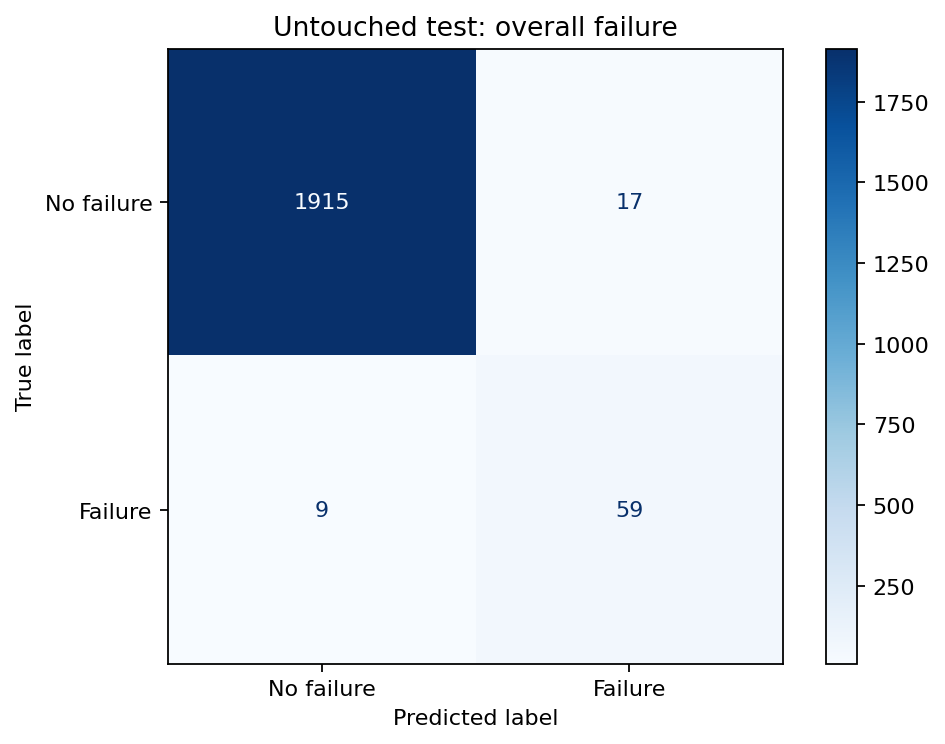

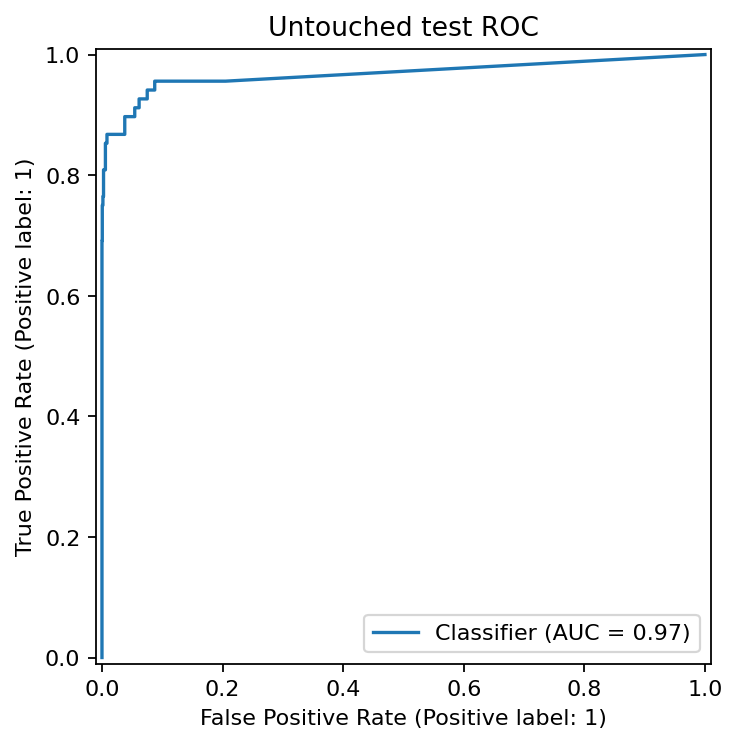

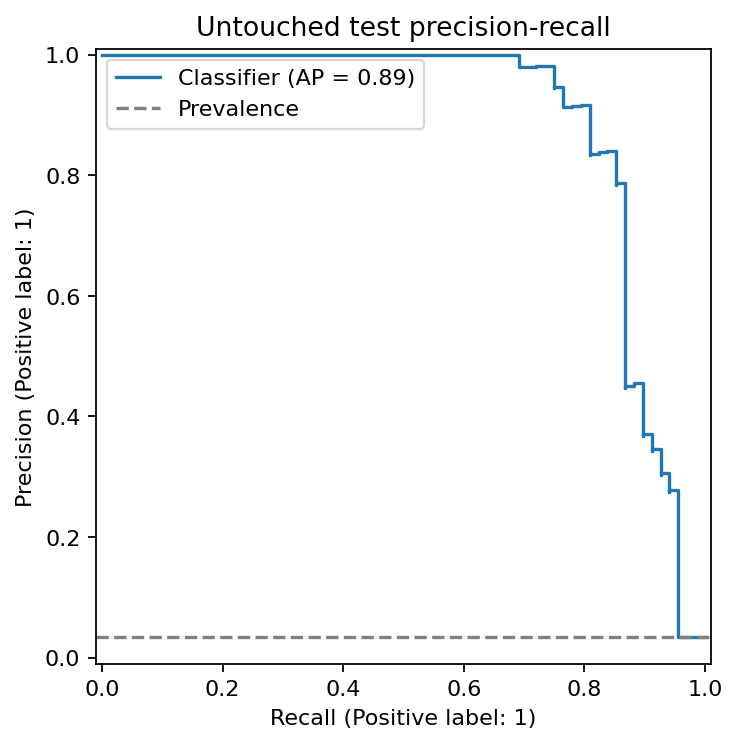

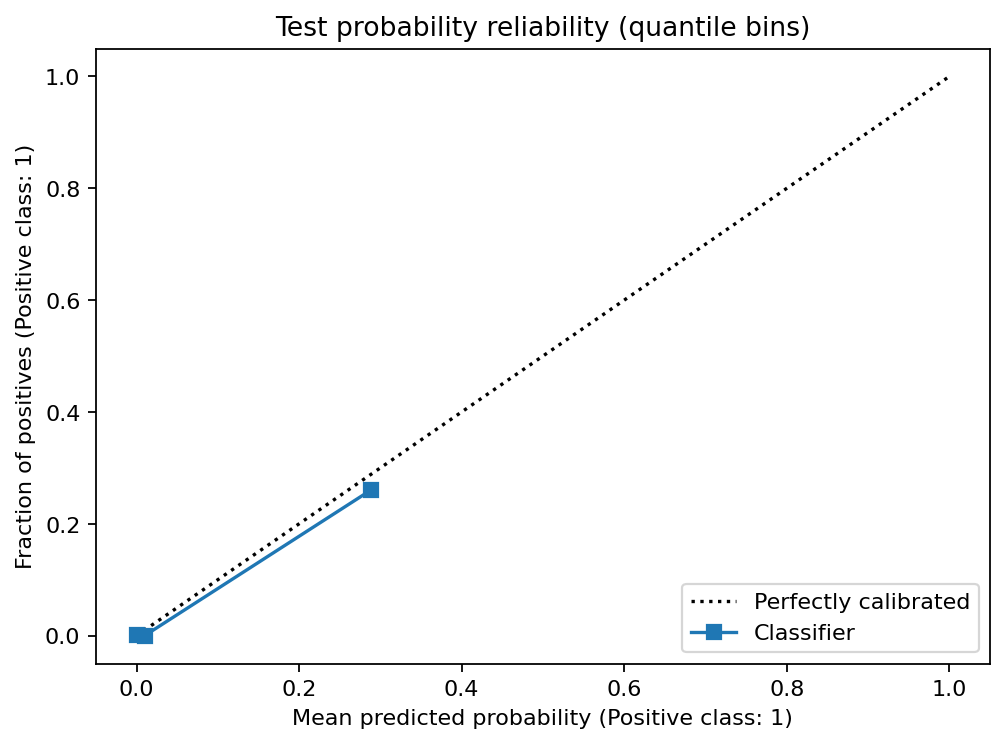

In [6]:
for figure in ['confusion_matrix.png','roc_curve.png','precision_recall_curve.png','calibration_curve.png']:
    display(Image(filename=str(ROOT/'reports/figures'/figure)))

## Failure modes and anomaly detection
HDF/PWF/OSF use separate binary classifiers where training support permits. TWF uses a clearly labeled stochastic wear-interval context indicator if too rare. RNF uses a descriptive training base rate with no individual sensor probability. Isolation Forest fits only normal training rows; unusualness is not confirmed failure.

,mode,n,positive_support,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,...,pr_auc_definition,pr_auc_trapezoidal,brier_score,component,train_positives,statistical_limit,tn,fp,fn,tp
0,TWF,2000,10,0.500000,0.917,0.858794,0.046512,0.800,0.917588,0.087912,...,average precision (non-interpolated),0.423756,0.083000,wear_interval_context_indicator_not_validated_...,21,Rare positive counts; exploratory metrics only...,1826,164,2,8
1,HDF,2000,29,0.178801,0.999,0.999493,0.935484,1.000,0.998985,0.966667,...,average precision (non-interpolated),0.984991,0.001695,independent_random_forest_uncalibrated_probabi...,70,Rare positive counts; exploratory metrics only...,1969,2,0,29
2,PWF,2000,13,0.670000,1.000,1.000000,1.000000,1.000,1.000000,1.000000,...,average precision (non-interpolated),1.000000,0.000000,independent_random_forest_uncalibrated_probabi...,58,Rare positive counts; exploratory metrics only...,1987,0,0,13
3,OSF,2000,16,0.989119,0.997,0.812500,1.000000,0.625,1.000000,0.769231,...,average precision (non-interpolated),0.987171,0.000505,independent_random_forest_uncalibrated_probabi...,62,Rare positive counts; exploratory metrics only...,1984,0,6,10
4,RNF,2000,4,0.500000,0.998,0.500000,0.000000,0.000,1.000000,0.000000,...,average precision (non-interpolated),0.501000,0.001996,constant_training_base_rate_baseline_no_sensor...,10,Rare positive counts; exploratory metrics only...,1996,0,4,0


{'normal_training_count': 5797,
 'contamination': 0.02,
 'test_anomaly_rate': 0.022,
 'failure_recall_as_novelty_flag': 0.16176470588235295,
 'normal_false_alert_rate': 0.017080745341614908,
 'score_meaning': 'Raw score is negative IsolationForest.score_samples (higher = more unusual). Display score is empirical percentile among normal training scores, not a failure probability. is_anomaly uses fitted contamination threshold.'}

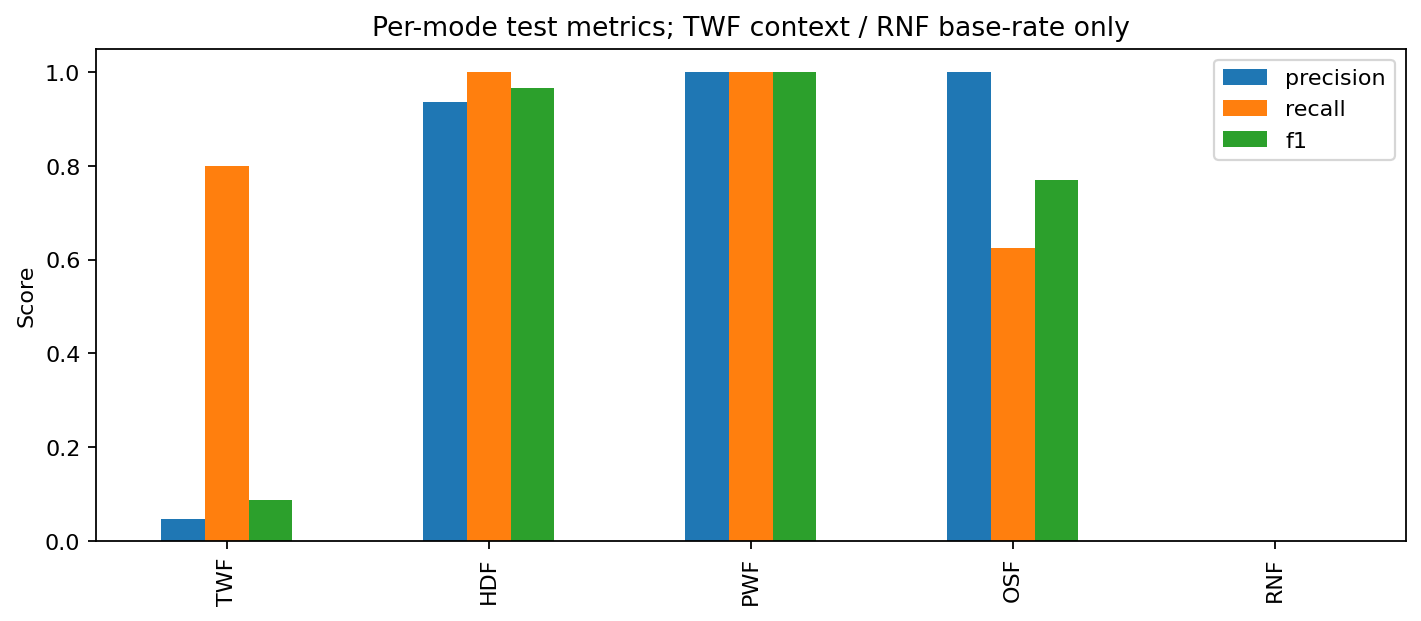

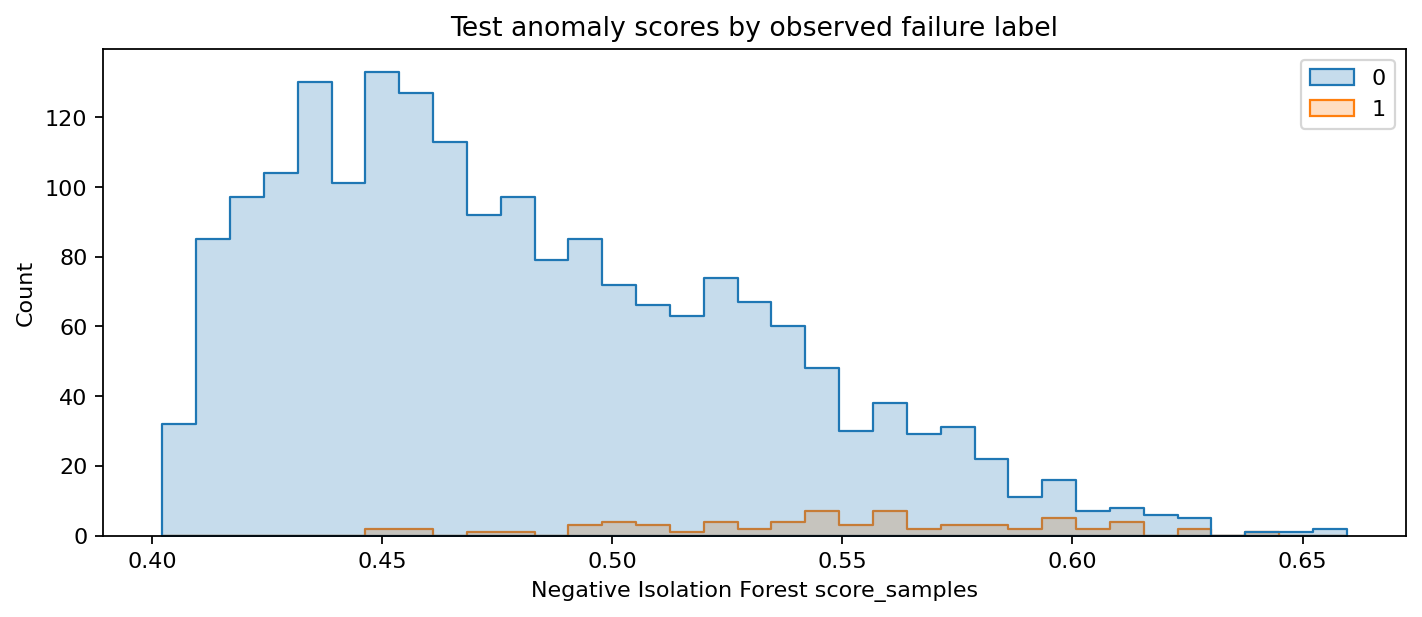

In [7]:
display(pd.read_csv(ROOT/'reports/metrics/failure_mode_metrics.csv'))
display(read_json(ROOT/'reports/metrics/anomaly_metrics.json'))
for figure in ['failure_mode_results.png','anomaly_score_distribution.png']:
    display(Image(filename=str(ROOT/'reports/figures'/figure)))

## Global and local explanations
Permutation importance is evaluated on validation rows. Offline Kernel SHAP explains deployed probabilities over six original inputs, including all derived recalculations. Runtime Tree SHAP explains the selected random forest over transformed inputs. All are associations, not proofs of physical causality.

,feature,mean_ap_decrease,std_ap_decrease
0,torque,0.676465,0.018704
1,air_temperature,0.519233,0.033940
2,rotational_speed,0.484076,0.034071
3,process_temperature,0.403284,0.014830
4,tool_wear,0.270042,0.012119
5,product_type,0.037356,0.009934


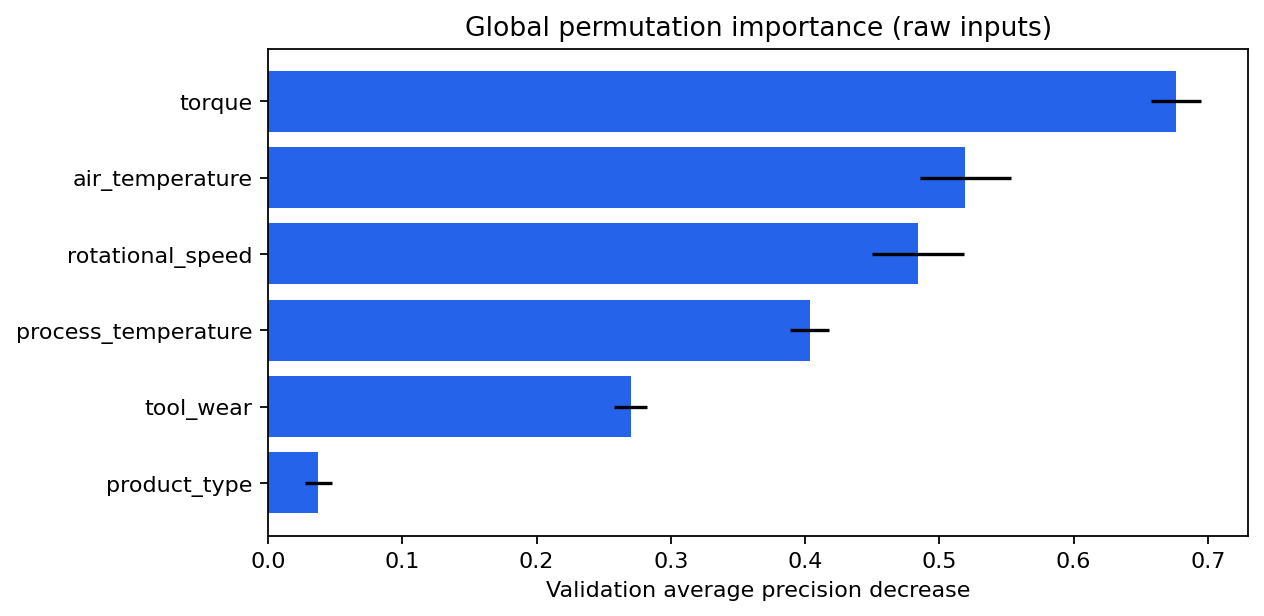

{'available': True,
 'method': 'Kernel SHAP on deployed probability, all six-feature coalitions, 12 training background rows',
 'feature_names': ['product_type',
  'air_temperature',
  'process_temperature',
  'rotational_speed',
  'torque',
  'tool_wear'],
 'base_value': 0.03177623149057087,
 'contributions': [[0.006012064739930499,
   -0.0035103354657767187,
   0.002996790035678913,
   0.0011641482088483388,
   -0.018065079461502452,
   -0.02037381954774945],
  [0.026624010604371962,
   0.14498808285056458,
   0.035805977418101737,
   0.1176007975157794,
   0.43484176423322535,
   0.16147129490661527]],
 'predictions': [0.0, 0.9531081590192291],
 'max_additivity_error': 0.0,
 'inputs': [{'product_type': 'L',
   'air_temperature': 298.1,
   'process_temperature': 308.6,
   'rotational_speed': 1450.0,
   'torque': 45.0,
   'tool_wear': 120.0},
  {'product_type': 'L',
   'air_temperature': 302.0,
   'process_temperature': 310.0,
   'rotational_speed': 1300.0,
   'torque': 65.0,
   'tool

In [8]:
display(pd.read_csv(ROOT/'reports/metrics/global_feature_importance.csv'))
display(Image(filename=str(ROOT/'reports/figures/feature_importance.png')))
display(read_json(ROOT/'reports/metrics/shap_explanations.json'))

## Manual predictions, serialization, and API contract

In [9]:
predictor=Predictor()
for example in ['manual_input','high_risk_input']:
    payload=read_json(ROOT/f'examples/{example}.json')
    result=predictor.predict(payload)
    assert 0<=result['failure_probability']<=1
    direct=predictor.model.predict_proba(pd.DataFrame([{k:payload[k] for k in FEATURES}]))[0,1]
    assert np.isclose(direct,result['failure_probability'])
    print(example,result['health_status'],result['failure_probability'])
    display(result)

C:\Users\vanda\OneDrive\Documents\ChatGPT\predictive maintenance agent for manufacturing\predictive_maintenance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


manual_input Healthy 0.0


{'prediction_id': '130dbcac-8784-4512-9416-50ed7bc73549',
 'prediction_timestamp': '2026-09-09T11:24:53.851584Z',
 'model_version': 'ai4i-pilot-1.0.0-2026-09-09',
 'machine_id': 'DEMO-001',
 'event_timestamp': '2026-09-09T10:00:00Z',
 'production_state': 'running',
 'validated_input': {'product_type': 'L',
  'air_temperature': 298.1,
  'process_temperature': 308.6,
  'rotational_speed': 1450.0,
  'torque': 45.0,
  'tool_wear': 120.0},
 'units': {'product_type': 'L/M/H',
  'air_temperature': 'K',
  'process_temperature': 'K',
  'rotational_speed': 'rpm',
  'torque': 'Nm',
  'tool_wear': 'min',
  'temperature_difference': 'K',
  'mechanical_power_w': 'W',
  'overstrain_measure': 'min*Nm'},
 'derived_values': {'temperature_difference': 10.5,
  'mechanical_power_w': 6832.9640215578,
  'overstrain_measure': 5400.0},
 'failure_probability': 0.0,
 'predicted_class': 'no_failure',
 'decision_threshold': 0.27904037338435955,
 'health_status': 'Healthy',
 'risk_level': 'Healthy',
 'urgency': 'Ro

high_risk_input Critical 0.9531081590192291


{'prediction_id': '648465c2-21a2-4ea8-8bf8-1072cba7c701',
 'prediction_timestamp': '2026-09-09T11:24:54.114275Z',
 'model_version': 'ai4i-pilot-1.0.0-2026-09-09',
 'machine_id': 'DEMO-002',
 'event_timestamp': '2026-09-09T10:00:00Z',
 'production_state': 'running',
 'validated_input': {'product_type': 'L',
  'air_temperature': 302.0,
  'process_temperature': 310.0,
  'rotational_speed': 1300.0,
  'torque': 65.0,
  'tool_wear': 220.0},
 'units': {'product_type': 'L/M/H',
  'air_temperature': 'K',
  'process_temperature': 'K',
  'rotational_speed': 'rpm',
  'torque': 'Nm',
  'tool_wear': 'min',
  'temperature_difference': 'K',
  'mechanical_power_w': 'W',
  'overstrain_measure': 'min*Nm'},
 'derived_values': {'temperature_difference': 8.0,
  'mechanical_power_w': 8848.81930761125,
  'overstrain_measure': 14300.0},
 'failure_probability': 0.9531081590192291,
 'predicted_class': 'failure',
 'decision_threshold': 0.27904037338435955,
 'health_status': 'Critical',
 'risk_level': 'Critical',


In [10]:
from src.schemas import SensorReading, PredictionResult
from pydantic import ValidationError
bad=read_json(ROOT/'examples/manual_input.json');bad['torque']=None
try:
    SensorReading.model_validate(bad)
except ValidationError as exc:
    print('Invalid input correctly rejected:',str(exc).splitlines()[0])
else:
    raise AssertionError('Invalid input accepted')
print('Input schema fields:',list(SensorReading.model_fields))
print('Output schema fields:',list(PredictionResult.model_fields))

Invalid input correctly rejected: 1 validation error for SensorReading
Input schema fields: ['product_type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_id', 'event_timestamp', 'production_state']
Output schema fields: ['prediction_id', 'prediction_timestamp', 'model_version', 'machine_id', 'event_timestamp', 'production_state', 'validated_input', 'units', 'derived_values', 'failure_probability', 'predicted_class', 'decision_threshold', 'health_status', 'risk_level', 'urgency', 'anomaly_score', 'anomaly_raw_score', 'is_anomaly', 'anomaly_explanation', 'likely_failure_modes', 'condition_evidence', 'contributing_features', 'explanation_method', 'explanation', 'recommended_maintenance_action', 'warnings', 'decision_support_notice', 'latency_ms']


## Controlled factory pilot
Map sensors and units, validate equipment history, calibrate thresholds, review cybersecurity, run shadow mode, obtain human approval, monitor input and prediction drift, and capture confirmed technician outcomes. Use `FACTORY_DEPLOYMENT_CHECKLIST.md`. Do not infer exact downtime or failure in the next X hours from AI4I.